# 05 — Tanimoto kNN Predictor

Similarity-weighted kNN on ECFP4 fingerprints (Tanimoto = Jaccard on bit vectors).

**Key property**: kNN directly exploits structural analogy — exactly what the test set
was designed around (analog expansion of 63 selective hits).  Scaffold-out CV will
*underestimate* its true test performance because CV forces held-out scaffolds, while
the actual test compounds are structurally close to training compounds.

**Workflow**: tune k via scaffold CV → blend with 03-ensemble → save `submissions/05_knn_blend.csv`

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

from pxr.paths import DATA_PROCESSED, SUBMISSIONS, FIGURES
from pxr.data import load_train, load_test
from pxr.chem import morgan_fp_batch
from pxr.eval import scaffold_kfold_indices, compute_metrics

plt.rcParams.update({"figure.dpi": 120})
print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── 2. Load data + fingerprints ───────────────────────────────────────────────
train_raw = load_train().dropna(subset=["pec50"])
cpd = pd.read_parquet(DATA_PROCESSED / "compounds.parquet")
train = train_raw.merge(cpd[["name", "std_smiles", "scaffold"]], on="name", how="left")
train["smi"] = train["std_smiles"].fillna(train["smiles"])
train = train.reset_index(drop=True)

test = load_test()

# Base ensemble (03) as blending partner
base_df = pd.read_csv(SUBMISSIONS / "03_ensemble_lgbm_chemprop.csv")
base_pred_map = dict(zip(base_df["Molecule Name"], base_df["pEC50"]))
base_preds = np.array([base_pred_map[n] for n in test["name"]])

print("Computing ECFP4 fingerprints (radius=2, 2048 bits)...")
# bool arrays required for sklearn's jaccard metric (= Tanimoto on bit vectors)
X_tr = morgan_fp_batch(train["smi"].tolist()).astype(bool)
X_te = morgan_fp_batch(test["smiles"].tolist()).astype(bool)
y_tr = train["pec50"].values

print(f"Train FP: {X_tr.shape},  Test FP: {X_te.shape}")
print(f"Training pEC50: {y_tr.min():.2f} – {y_tr.max():.2f}")

Computing ECFP4 fingerprints (radius=2, 2048 bits)...


Train FP: (4153, 2048),  Test FP: (513, 2048)
Training pEC50: 1.61 – 7.55


In [3]:
# ── 3. Scaffold CV — tune k ───────────────────────────────────────────────────
scaffolds = train["scaffold"].tolist()
splits = scaffold_kfold_indices(scaffolds, n_splits=5, seed=42)
k_values = [1, 3, 5, 10, 20, 50]

rows = []
for k in k_values:
    for fold, (tr_idx, va_idx) in enumerate(splits):
        nn = NearestNeighbors(n_neighbors=k, metric="jaccard",
                              algorithm="brute", n_jobs=4)
        nn.fit(X_tr[tr_idx])
        dists, idxs = nn.kneighbors(X_tr[va_idx])
        sims = 1.0 - dists
        w = sims / (sims.sum(axis=1, keepdims=True) + 1e-9)
        preds = (w * y_tr[tr_idx][idxs]).sum(axis=1)
        m = compute_metrics(y_tr[va_idx], preds)
        m["fold"] = fold; m["k"] = k
        rows.append(m)

cv_df = pd.DataFrame(rows)
summary = cv_df.groupby("k")[["RAE", "MAE", "Spearman"]].mean().round(4)
print("Scaffold 5-fold CV — Tanimoto-weighted kNN:")
print(summary.to_string())
best_k = int(summary["RAE"].idxmin())
print(f"\nBest k = {best_k}  (mean scaffold-CV RAE = {summary.loc[best_k, 'RAE']:.4f})")
print()
print("NOTE: scaffold-out CV underestimates kNN performance on the actual test set,")
print("which was built by analog expansion (test compounds HAVE training neighbours).")

Scaffold 5-fold CV — Tanimoto-weighted kNN:
       RAE     MAE  Spearman
k                           
1   0.9379  0.8461    0.4345
3   0.7962  0.7189    0.5253
5   0.7606  0.6864    0.5597
10  0.7423  0.6703    0.5877
20  0.7397  0.6681    0.6075
50  0.7627  0.6895    0.6181

Best k = 20  (mean scaffold-CV RAE = 0.7397)

NOTE: scaffold-out CV underestimates kNN performance on the actual test set,
which was built by analog expansion (test compounds HAVE training neighbours).


In [4]:
# ── 4. Test-set predictions at best_k ─────────────────────────────────────────
nn_full = NearestNeighbors(n_neighbors=best_k, metric="jaccard",
                           algorithm="brute", n_jobs=4)
nn_full.fit(X_tr)
dists_te, idxs_te = nn_full.kneighbors(X_te)
sims_te = 1.0 - dists_te
w_te    = sims_te / (sims_te.sum(axis=1, keepdims=True) + 1e-9)
knn_preds = (w_te * y_tr[idxs_te]).sum(axis=1)

top1_sim = sims_te[:, 0]
print(f"kNN predictions: {knn_preds.min():.3f} – {knn_preds.max():.3f}")
print(f"Top-1 Tanimoto similarity to training:")
print(f"  Mean {top1_sim.mean():.3f}  Median {np.median(top1_sim):.3f}  "
      f"Min {top1_sim.min():.3f}  Max {top1_sim.max():.3f}")
print(f"Compounds with top-1 sim > 0.7: {(top1_sim > 0.7).sum()}")
print(f"Compounds with top-1 sim > 0.5: {(top1_sim > 0.5).sum()}")

kNN predictions: 3.422 – 5.537
Top-1 Tanimoto similarity to training:
  Mean 0.532  Median 0.523  Min 0.323  Max 0.806
Compounds with top-1 sim > 0.7: 12
Compounds with top-1 sim > 0.5: 330


In [5]:
# ── 5. Blend weight optimisation via CV ───────────────────────────────────────
# For each fold: LGBM predictions not available here, so blend kNN with base
# preds on test set using a range of weights, guided by CV kNN vs lgbm RAE.

lgbm_rae_cv = 0.5675   # from notebook 02 (lgbm_cb scaffold CV)
knn_rae_cv  = summary.loc[best_k, "RAE"]

# Inverse-RAE weighting as a principled starting point
w_knn_inv = (1/knn_rae_cv) / (1/knn_rae_cv + 1/lgbm_rae_cv)
print(f"LGBM scaffold-CV RAE: {lgbm_rae_cv:.4f}")
print(f"kNN  scaffold-CV RAE: {knn_rae_cv:.4f}")
print(f"Inverse-RAE suggested kNN weight: {w_knn_inv:.3f}")
print()
print("Blending at several weights (kNN × w + base × (1-w)):")
for w in [0.2, 0.3, 0.4, 0.5]:
    blended = w * knn_preds + (1-w) * base_preds
    shift = (blended - base_preds).mean()
    print(f"  w={w:.1f}  mean_shift={shift:+.4f}  "
          f"range=[{blended.min():.2f}, {blended.max():.2f}]")

LGBM scaffold-CV RAE: 0.5675
kNN  scaffold-CV RAE: 0.7397
Inverse-RAE suggested kNN weight: 0.434

Blending at several weights (kNN × w + base × (1-w)):
  w=0.2  mean_shift=-0.0025  range=[2.63, 5.71]
  w=0.3  mean_shift=-0.0037  range=[2.73, 5.67]
  w=0.4  mean_shift=-0.0049  range=[2.83, 5.62]
  w=0.5  mean_shift=-0.0062  range=[2.93, 5.57]


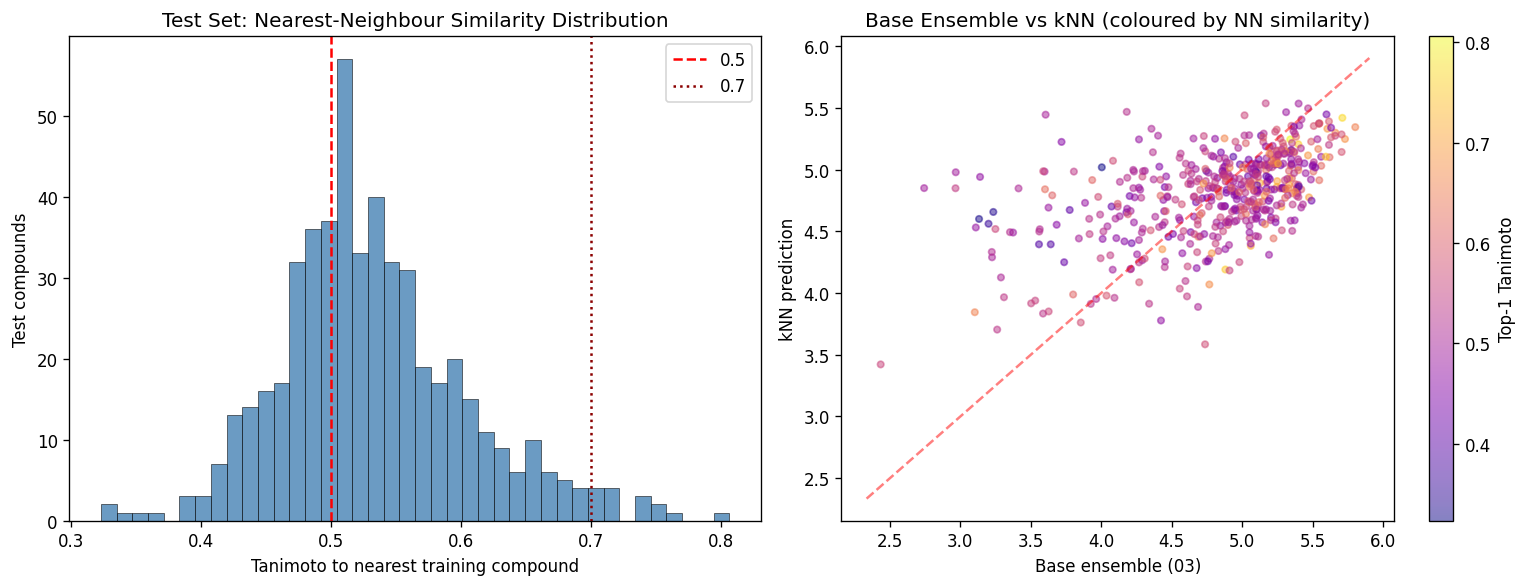

Saved 05_knn_similarity.png


In [6]:
# ── 6. Visualise test similarity distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(top1_sim, bins=40, color="steelblue", edgecolor="k", linewidth=0.4, alpha=0.8)
ax.axvline(0.5, color="red",    linestyle="--", lw=1.5, label="0.5")
ax.axvline(0.7, color="darkred",linestyle=":",  lw=1.5, label="0.7")
ax.set_xlabel("Tanimoto to nearest training compound")
ax.set_ylabel("Test compounds")
ax.set_title("Test Set: Nearest-Neighbour Similarity Distribution")
ax.legend()

ax = axes[1]
ax.scatter(base_preds, knn_preds, alpha=0.5, s=15, c=top1_sim, cmap="plasma")
plt.colorbar(axes[1].collections[0], ax=axes[1], label="Top-1 Tanimoto")
lo = min(base_preds.min(), knn_preds.min()) - 0.1
hi = max(base_preds.max(), knn_preds.max()) + 0.1
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, alpha=0.5)
ax.set_xlabel("Base ensemble (03)")
ax.set_ylabel("kNN prediction")
ax.set_title("Base Ensemble vs kNN (coloured by NN similarity)")

plt.tight_layout()
plt.savefig(FIGURES / "05_knn_similarity.png", bbox_inches="tight")
plt.show()
print("Saved 05_knn_similarity.png")

In [7]:
# ── 7. Save submission ────────────────────────────────────────────────────────
# Use w=0.4 as a conservative blend (kNN is strong on analogs but CV underestimates it)
W_KNN = 0.40
final_preds = W_KNN * knn_preds + (1.0 - W_KNN) * base_preds

# Clip to training range ± 0.5
lo_clip = y_tr.min() - 0.5
hi_clip = y_tr.max() + 0.5
final_preds = np.clip(final_preds, lo_clip, hi_clip)

submission = pd.DataFrame({
    "Molecule Name": test["name"].values,
    "SMILES":        test["smiles"].values,
    "pEC50":         final_preds,
})
assert len(submission) == 513
assert submission["pEC50"].notna().all()

out_path = SUBMISSIONS / "05_knn_blend.csv"
submission.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"kNN weight: {W_KNN:.2f}")
print(submission["pEC50"].describe().round(3))

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\05_knn_blend.csv
kNN weight: 0.40
count    513.000
mean       4.811
std        0.436
min        2.829
25%        4.578
50%        4.905
75%        5.122
max        5.620
Name: pEC50, dtype: float64
